In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# ACC e ITR

In [3]:
experiments = [
        exp.name for exp in Path("../louo_experiments/thesis/").iterdir() if exp.is_dir()
]
df_list = []
for experiment in experiments:
    exp_path = Path("../louo_experiments/thesis/").joinpath(experiment)
    for setup in exp_path.iterdir():
        if setup.is_dir():
            print(f"Experiment: {experiment}, Setup: {setup.name}")
            metrics_path = setup.joinpath("metricas.csv")
            if metrics_path.exists():
                df = pd.read_csv(metrics_path)
                df["experiment"] = experiment
                df["window"] = float(setup.name.split("_")[-2])
                df["frequency"] = int(setup.name.split("_")[-4])
                df["users"] = int(setup.name.split("_")[0])
                df_list.append(df)
results = pd.concat(df_list, ignore_index=True)

Experiment: fbcca_eegnet_8_2, Setup: 35_users_40_freqs_0.6_s
Experiment: fbcca_eegnet_8_2, Setup: 35_users_40_freqs_1.0_s
Experiment: fbcca_eegnet_8_2, Setup: 35_users_40_freqs_0.8_s
Experiment: fbcca_eegnet_8_2, Setup: 35_users_40_freqs_0.4_s
Experiment: eegnet_4_2_no_norm, Setup: 35_users_40_freqs_0.6_s
Experiment: eegnet_4_2_no_norm, Setup: 35_users_40_freqs_1.0_s
Experiment: eegnet_4_2_no_norm, Setup: 35_users_40_freqs_0.8_s
Experiment: eegnet_4_2_no_norm, Setup: 35_users_40_freqs_0.4_s
Experiment: fbcca_dnn, Setup: 35_users_40_freqs_0.6_s
Experiment: fbcca_dnn, Setup: 35_users_40_freqs_1.0_s
Experiment: fbcca_dnn, Setup: 35_users_40_freqs_0.8_s
Experiment: fbcca_dnn, Setup: 35_users_40_freqs_0.4_s
Experiment: dnn, Setup: 35_users_40_freqs_0.6_s
Experiment: dnn, Setup: 35_users_40_freqs_1.0_s
Experiment: dnn, Setup: 35_users_40_freqs_0.8_s
Experiment: dnn, Setup: 35_users_40_freqs_0.4_s
Experiment: CCA, Setup: 35_users_40_freqs_0.6_s
Experiment: CCA, Setup: 35_users_40_freqs_1.0_s


In [4]:
results

,usuario,acuracia,recall,f1-score,experiment,window,frequency,users
0,1,0.637500,0.637500,0.630573,fbcca_eegnet_8_2,0.6,40,35
1,2,0.566667,0.566667,0.558351,fbcca_eegnet_8_2,0.6,40,35
2,3,0.829167,0.829167,0.827943,fbcca_eegnet_8_2,0.6,40,35
3,4,0.408333,0.408333,0.394084,fbcca_eegnet_8_2,0.6,40,35
4,5,0.329167,0.329167,0.315348,fbcca_eegnet_8_2,0.6,40,35
...,...,...,...,...,...,...,...,...
1395,31,0.458333,0.458333,0.442561,cca_dnn,0.4,40,35
1396,32,0.850000,0.850000,0.849446,cca_dnn,0.4,40,35
1397,33,0.279167,0.279167,0.274045,cca_dnn,0.4,40,35
1398,34,0.408333,0.408333,0.393729,cca_dnn,0.4,40,35


In [4]:
from math import log2

# Resumos de acurácia: média, desvio-padrão (STD) e erro-padrão (SEM).
results_means = (
    results.groupby(["experiment", "window"])
    .agg(
        acuracia=("acuracia", "mean"),
        acuracia_std=("acuracia", "std"),
        acuracia_sem=("acuracia", "sem"),
    )
    .reset_index()
)
print(results_means)


# ============ CÁLCULO DO ITR ============
def itr(n, p, t):
    """
    Calcula a taxa de transferência de informação em bits por minuto.
    """
    if p < 0 or 1 < p:
        raise ValueError(
            "stats:itr:BadInputValue " + "A acurácia deve estar entre 0 e 1."
        )
    elif p < 1 / n:
        itr_value = 0
    elif p == 1:
        itr_value = log2(n) * 60 / t
    else:
        itr_value = (
            log2(n)
            + p * log2(p)
            + (1 - p) * log2((1 - p) / (n - 1))
        ) * 60 / t
    return itr_value


n_classes = 40
tempo_desvio_ocular = 0.55
results["itr"] = results.apply(
    lambda row: itr(n_classes, row["acuracia"], row["window"] + tempo_desvio_ocular),
    axis=1,
)

# Resumos de ITR: média, desvio-padrão (STD) e erro-padrão (SEM).
results_itr = (
    results.groupby(["experiment", "window"])
    .agg(
        itr=("itr", "mean"),
        itr_std=("itr", "std"),
        itr_sem=("itr", "sem"),
    )
    .reset_index()
)

print("\nValores de ITR por experimento e janela:")
print(results_itr)

            experiment  window  acuracia  acuracia_std  acuracia_sem
0                  CCA     0.4  0.110119      0.059231      0.010012
1                  CCA     0.6  0.241667      0.131315      0.022196
2                  CCA     0.8  0.398095      0.186734      0.031564
3                  CCA     1.0  0.532143      0.213633      0.036110
4           CCA_vs_SVM     1.0  0.771429      0.192968      0.032618
5              cca_dnn     0.4  0.382976      0.205168      0.034680
6              cca_dnn     0.6  0.509167      0.223602      0.037796
7              cca_dnn     0.8  0.645833      0.219737      0.037142
8              cca_dnn     1.0  0.717857      0.219140      0.037041
9       cca_eegnet_4_2     0.4  0.262143      0.139203      0.023530
10      cca_eegnet_4_2     0.6  0.383690      0.190221      0.032153
11      cca_eegnet_4_2     0.8  0.556548      0.221695      0.037473
12      cca_eegnet_4_2     1.0  0.625000      0.223140      0.037718
13      cca_eegnet_8_2     0.4  0.

# P-values usando ttest

Comparar as versões com e sem CCA, e com e sem FBCCA. A hipótese nula é que as duas versões têm a mesma média de ACC ou ITR. A hipótese alternativa é que a versão com CCA ou FBCCA tem média maior.

In [6]:
from scipy import stats

# Calculate p-values for paired t-tests between experiments at each window
# For each window, compare each pair of experiments
p_values_dict = {}

for window in sorted(results["window"].unique()):
    window_data = results[results["window"] == window]
    experiments_list = sorted(window_data["experiment"].unique())

    p_values_dict[window] = {}

    for i, exp1 in enumerate(experiments_list):
        for exp2 in experiments_list[i + 1 :]:
            data1 = window_data[window_data["experiment"] == exp1]["acuracia"].values
            print(exp1, window_data[window_data["experiment"] == exp1]["acuracia"])
            data2 = window_data[window_data["experiment"] == exp2]["acuracia"].values
            print(exp2, window_data[window_data["experiment"] == exp2]["acuracia"])

            # Paired t-test
            t_stat, p_value = stats.ttest_rel(data1, data2)
            p_values_dict[window][(exp1, exp2)] = p_value


# Create a function to get significance marker
def get_significance(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"


print("P-values from paired t-tests:")
for window, pairs in p_values_dict.items():
    print(f"\nWindow: {window}s")
    for (exp1, exp2), p_val in pairs.items():
        sig = get_significance(p_val)
        print(f"  {exp1} vs {exp2}: p={p_val:.4f} {sig}")

CCA 665    0.108333
666    0.100000
667    0.225000
668    0.266667
669    0.095833
670    0.095833
671    0.070833
672    0.070833
673    0.100000
674    0.091667
675    0.062500
676    0.083333
677    0.083333
678    0.204167
679    0.066667
680    0.058333
681    0.041667
682    0.154167
683    0.041667
684    0.041667
685    0.091667
686    0.141667
687    0.100000
688    0.112500
689    0.166667
690    0.258333
691    0.087500
692    0.125000
693    0.087500
694    0.058333
695    0.200000
696    0.116667
697    0.062500
698    0.129167
699    0.054167
Name: acuracia, dtype: float64
cca_dnn 1365    0.608333
1366    0.629167
1367    0.808333
1368    0.254167
1369    0.283333
1370    0.491667
1371    0.358333
1372    0.270833
1373    0.433333
1374    0.516667
1375    0.087500
1376    0.229167
1377    0.100000
1378    0.045833
1379    0.370833
1380    0.354167
1381    0.233333
1382    0.679167
1383    0.145833
1384    0.362500
1385    0.316667
1386    0.695833
1387    0.133333
1388  

In [7]:
# ============ CALCULATE P-VALUES FOR ITR ============
# Calculate separate p-values for ITR (independent of accuracy p-values)

p_values_dict_itr = {}

for window in sorted(results["window"].unique()):
    window_data = results[results["window"] == window]
    experiments_list = sorted(window_data["experiment"].unique())

    p_values_dict_itr[window] = {}

    for i, exp1 in enumerate(experiments_list):
        for exp2 in experiments_list[i + 1 :]:
            # Use ITR values instead of accuracy
            data1 = window_data[window_data["experiment"] == exp1]["itr"].values
            data2 = window_data[window_data["experiment"] == exp2]["itr"].values

            # Paired t-test on ITR values
            t_stat, p_value = stats.ttest_rel(data1, data2)
            p_values_dict_itr[window][(exp1, exp2)] = p_value


print("\nP-values from paired t-tests (ITR):")
for window, pairs in p_values_dict_itr.items():
    print(f"\nWindow: {window}s")
    for (exp1, exp2), p_val in pairs.items():
        sig = get_significance(p_val)
        print(f"  {exp1} vs {exp2}: p={p_val:.4f} {sig}")


P-values from paired t-tests (ITR):

Window: 0.4s
  CCA vs cca_dnn: p=0.0000 ***
  CCA vs cca_eegnet_4_2: p=0.0000 ***
  CCA vs cca_eegnet_8_2: p=0.0000 ***
  CCA vs dnn: p=0.0000 ***
  CCA vs eegnet_4_2_no_norm: p=0.0000 ***
  CCA vs eegnet_8_2_no_norm: p=0.0000 ***
  CCA vs fbcca_dnn: p=0.0000 ***
  CCA vs fbcca_eegnet_4_2: p=0.0000 ***
  CCA vs fbcca_eegnet_8_2: p=0.0000 ***
  cca_dnn vs cca_eegnet_4_2: p=0.0000 ***
  cca_dnn vs cca_eegnet_8_2: p=0.0000 ***
  cca_dnn vs dnn: p=0.0790 ns
  cca_dnn vs eegnet_4_2_no_norm: p=0.0000 ***
  cca_dnn vs eegnet_8_2_no_norm: p=0.0000 ***
  cca_dnn vs fbcca_dnn: p=0.2105 ns
  cca_dnn vs fbcca_eegnet_4_2: p=0.0000 ***
  cca_dnn vs fbcca_eegnet_8_2: p=0.0000 ***
  cca_eegnet_4_2 vs cca_eegnet_8_2: p=0.0000 ***
  cca_eegnet_4_2 vs dnn: p=0.0000 ***
  cca_eegnet_4_2 vs eegnet_4_2_no_norm: p=0.0365 *
  cca_eegnet_4_2 vs eegnet_8_2_no_norm: p=0.0062 **
  cca_eegnet_4_2 vs fbcca_dnn: p=0.0000 ***
  cca_eegnet_4_2 vs fbcca_eegnet_4_2: p=0.1595 ns
  cc

In [8]:
results_means

,experiment,window,acuracia,acuracia_sem
0,CCA,0.4,0.110119,0.010012
1,CCA,0.6,0.241667,0.022196
2,CCA,0.8,0.398095,0.031564
3,CCA,1.0,0.532143,0.036110
4,cca_dnn,0.4,0.382976,0.034680
5,cca_dnn,0.6,0.509167,0.037796
6,cca_dnn,0.8,0.645833,0.037142
7,cca_dnn,1.0,0.717857,0.037041
8,cca_eegnet_4_2,0.4,0.262143,0.023530
9,cca_eegnet_4_2,0.6,0.383690,0.032153


# Graficos

## Acurácia e ITR médias por tamanho de janela

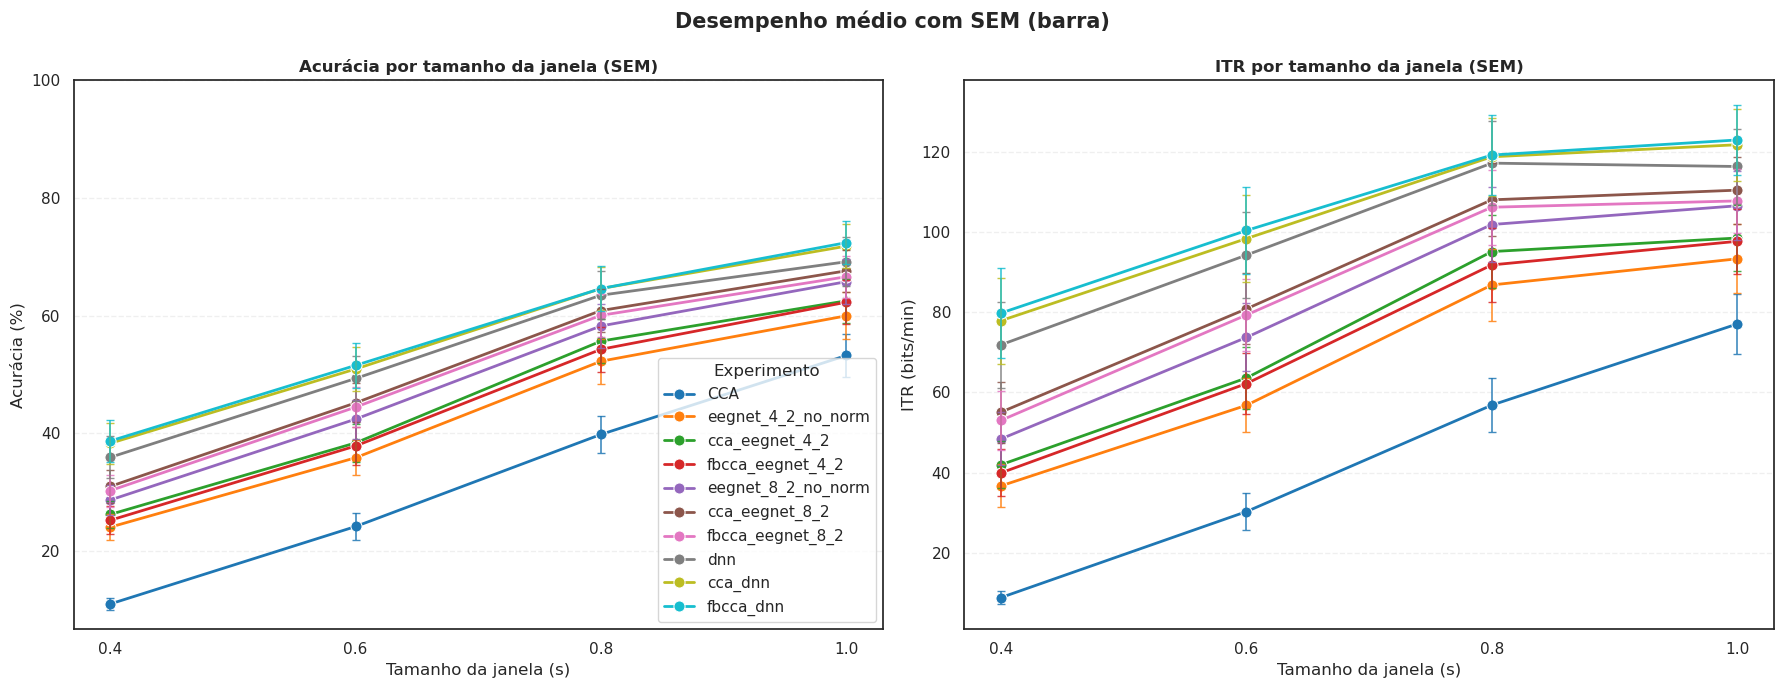

Variabilidade reportada: SEM
Visualização da variabilidade: barra


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tipo de variabilidade: "sem" ou "std".
tipo_erro = "sem"
# Forma de exibição: "sombreamento" ou "barra".
tipo_visualizacao = "barra"

if tipo_erro not in {"sem", "std"}:
    raise ValueError("tipo_erro deve ser 'sem' ou 'std'.")
if tipo_visualizacao not in {"sombreamento", "barra"}:
    raise ValueError("tipo_visualizacao deve ser 'sombreamento' ou 'barra'.")

coluna_erro_acuracia = f"acuracia_{tipo_erro}"
coluna_erro_itr = f"itr_{tipo_erro}"

sns.set_theme(style="white", context="notebook")
tab10 = sns.color_palette("tab10")
custom_palette = {
    "CCA": tab10[0],
    "eegnet_4_2_no_norm": tab10[1],
    "cca_eegnet_4_2": tab10[2],
    "fbcca_eegnet_4_2": tab10[3],
    "eegnet_8_2_no_norm": tab10[4],
    "cca_eegnet_8_2": tab10[5],
    "fbcca_eegnet_8_2": tab10[6],
    "dnn": tab10[7],
    "cca_dnn": tab10[8],
    "fbcca_dnn": tab10[9],
}

available_experiments = sorted(results_means["experiment"].unique())
experiments = [
    experiment
    for experiment in custom_palette
    if experiment in available_experiments
]

results_means_plot = results_means.copy()
results_means_plot[["acuracia", "acuracia_std", "acuracia_sem"]] *= 100


def adicionar_variabilidade(axis, data, eixo_x, eixo_y, coluna_erro, color):
    data = data.sort_values(eixo_x)
    if tipo_visualizacao == "sombreamento":
        axis.fill_between(
            data[eixo_x].to_numpy(),
            (data[eixo_y] - data[coluna_erro]).to_numpy(),
            (data[eixo_y] + data[coluna_erro]).to_numpy(),
            alpha=0.2,
            color=color,
        )
    else:
        axis.errorbar(
            data[eixo_x],
            data[eixo_y],
            yerr=data[coluna_erro],
            fmt="none",
            ecolor=color,
            elinewidth=1.2,
            capsize=3,
            alpha=0.85,
        )


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.lineplot(
    data=results_means_plot[results_means_plot["experiment"].isin(experiments)],
    x="window",
    y="acuracia",
    hue="experiment",
    hue_order=experiments,
    marker="o",
    markersize=8,
    linewidth=2,
    palette=custom_palette,
    ax=ax1,
)

for experiment in experiments:
    data = results_means_plot[
        results_means_plot["experiment"] == experiment
    ]
    adicionar_variabilidade(
        ax1, data, "window", "acuracia", coluna_erro_acuracia, custom_palette[experiment]
    )

ax1.set_xlabel("Tamanho da janela (s)")
ax1.set_ylabel("Acurácia (%)")
ax1.set_title(f"Acurácia por tamanho da janela ({tipo_erro.upper()})", fontweight="bold")
ax1.set_xticks(sorted(results_means["window"].unique()))
ax1.set_ylim(top=100)
ax1.grid(axis="y", alpha=0.3, linestyle="--")

sns.lineplot(
    data=results_itr[results_itr["experiment"].isin(experiments)],
    x="window",
    y="itr",
    hue="experiment",
    hue_order=experiments,
    marker="o",
    markersize=8,
    linewidth=2,
    palette=custom_palette,
    ax=ax2,
    legend=False,
)

for experiment in experiments:
    data = results_itr[results_itr["experiment"] == experiment]
    adicionar_variabilidade(
        ax2, data, "window", "itr", coluna_erro_itr, custom_palette[experiment]
    )

ax2.set_xlabel("Tamanho da janela (s)")
ax2.set_ylabel("ITR (bits/min)")
ax2.set_title(f"ITR por tamanho da janela ({tipo_erro.upper()})", fontweight="bold")
ax2.set_xticks(sorted(results_itr["window"].unique()))
ax2.grid(axis="y", alpha=0.3, linestyle="--")

handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, experiments, title="Experimento", loc="lower right")
fig.suptitle(
    f"Desempenho médio com {tipo_erro.upper()} ({tipo_visualizacao})",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

print(f"Variabilidade reportada: {tipo_erro.upper()}")
print(f"Visualização da variabilidade: {tipo_visualizacao}")

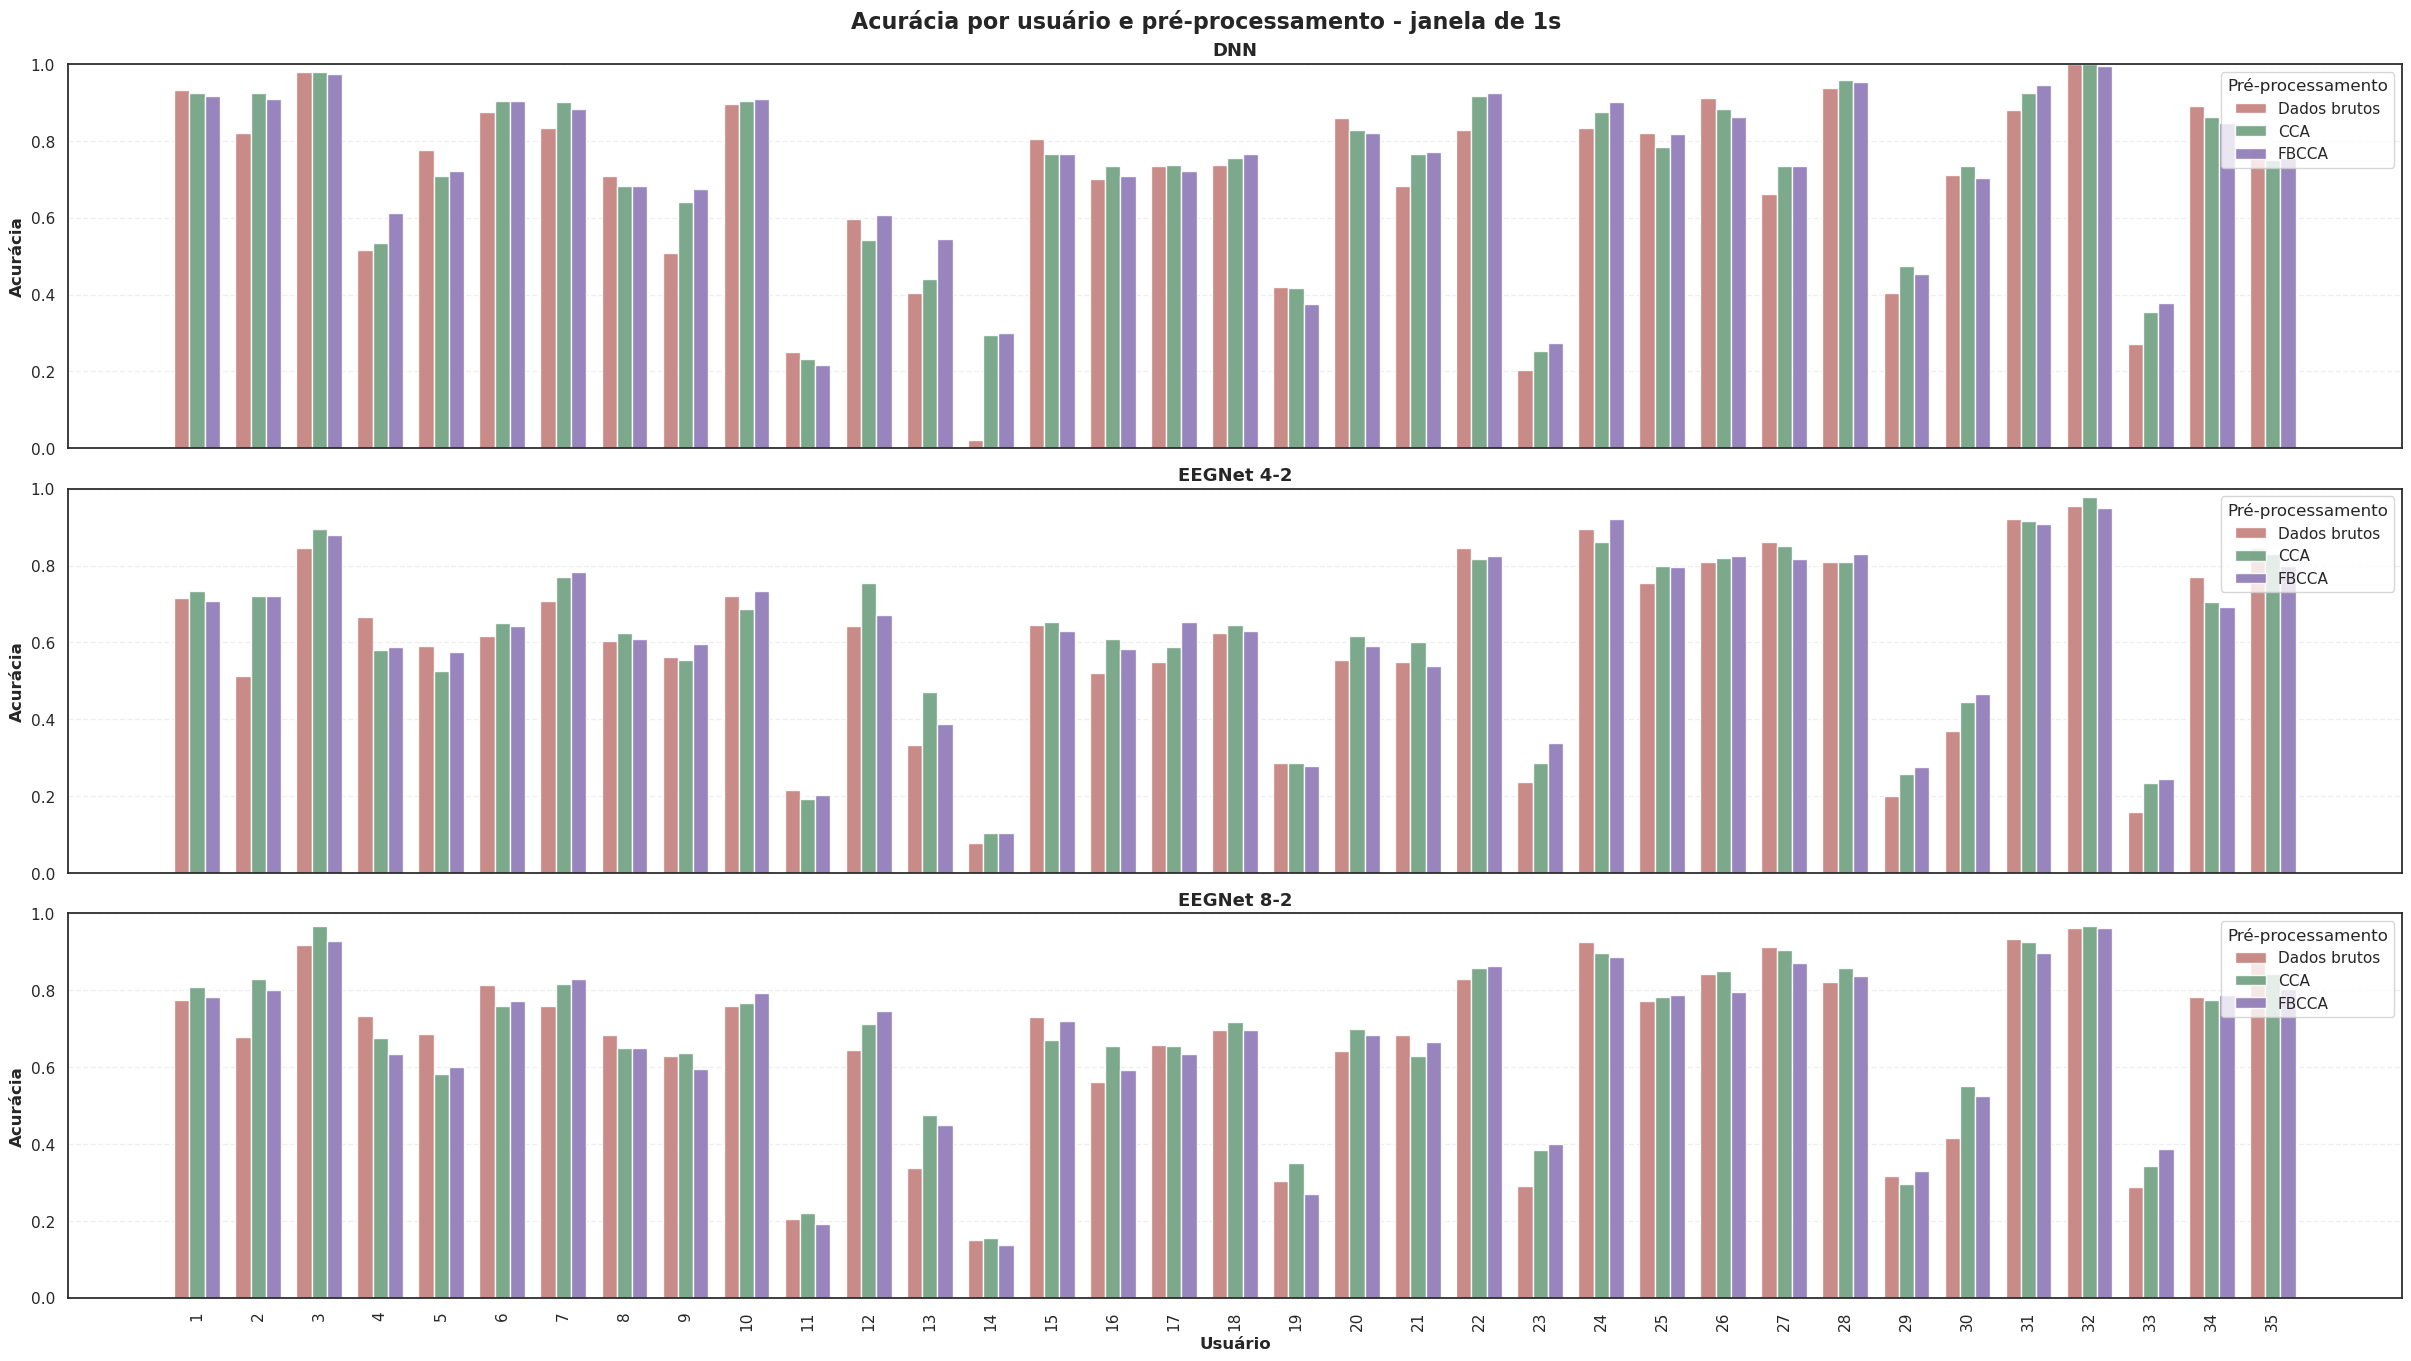

Janela plotada: 1s
Usuários mostrados: 35


In [8]:
# Acurácia por usuário na janela de 1s, agrupada por rede e pré-processamento
import matplotlib.pyplot as plt
import numpy as np

window_to_plot = 1.0
network_groups = {
    "DNN": ["dnn", "cca_dnn", "fbcca_dnn"],
    "EEGNet 4-2": [
        "eegnet_4_2_no_norm",
        "cca_eegnet_4_2",
        "fbcca_eegnet_4_2",
    ],
    "EEGNet 8-2": [
        "eegnet_8_2_no_norm",
        "cca_eegnet_8_2",
        "fbcca_eegnet_8_2",
    ],
}
preprocessing_labels = {
    "dnn": "Dados brutos",
    "cca_dnn": "CCA",
    "fbcca_dnn": "FBCCA",
    "eegnet_4_2_no_norm": "Dados brutos",
    "cca_eegnet_4_2": "CCA",
    "fbcca_eegnet_4_2": "FBCCA",
    "eegnet_8_2_no_norm": "Dados brutos",
    "cca_eegnet_8_2": "CCA",
    "fbcca_eegnet_8_2": "FBCCA",
}
preprocessing_colors = {
    "Dados brutos": "#c47f7a",
    "CCA": "#6e9f80",
    "FBCCA": "#8e78b7",
}

if window_to_plot not in results["window"].unique():
    raise ValueError(f"A janela de {window_to_plot:g}s não está disponível.")

users = sorted(results["usuario"].unique())
window_data = results[results["window"] == window_to_plot]
user_accuracy = (
    window_data.groupby(["usuario", "experiment"], as_index=False)["acuracia"]
    .mean()
)

fig, axes = plt.subplots(
    len(network_groups),
    1,
    figsize=(24, 4.5 * len(network_groups)),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)
x = np.arange(len(users))
bar_width = 0.25

for axis, (network_name, experiments_group) in zip(axes, network_groups.items()):
    for offset, experiment in enumerate(experiments_group):
        experiment_data = user_accuracy[
            user_accuracy["experiment"] == experiment
        ].set_index("usuario")["acuracia"]
        values = experiment_data.reindex(users).to_numpy()
        label = preprocessing_labels[experiment]
        axis.bar(
            x + (offset - 1) * bar_width,
            values,
            width=bar_width,
            label=label,
            color=preprocessing_colors[label],
            alpha=0.9,
        )

    axis.set_title(
        network_name,
        fontsize=13,
        fontweight="bold",
    )
    axis.set_ylabel("Acurácia", fontweight="bold")
    axis.grid(axis="y", linestyle="--", alpha=0.3)
    axis.set_ylim(0, 1)
    axis.legend(loc="upper right", title="Pré-processamento")

axes[-1].set_xlabel("Usuário", fontweight="bold")
axes[-1].set_xticks(x)
axes[-1].set_xticklabels([str(user) for user in users], rotation=90)
fig.suptitle(
    f"Acurácia por usuário e pré-processamento - janela de {window_to_plot:g}s",
    fontsize=16,
    fontweight="bold",
)
plt.show()

print(f"Janela plotada: {window_to_plot:g}s")
print(f"Usuários mostrados: {len(users)}")

In [11]:
# Contagem de usuários: Dados brutos versus Dados transformados (CCA/FBCCA)
network_groups = {
    "DNN": ["dnn", "cca_dnn", "fbcca_dnn"],
    "EEGNet 4-2": [
        "eegnet_4_2_no_norm",
        "cca_eegnet_4_2",
        "fbcca_eegnet_4_2",
    ],
    "EEGNet 8-2": [
        "eegnet_8_2_no_norm",
        "cca_eegnet_8_2",
        "fbcca_eegnet_8_2",
    ],
}

counts = []
for window in sorted(results["window"].unique()):
    window_data = results[results["window"] == window]
    user_accuracy = (
        window_data.groupby(["usuario", "experiment"], as_index=False)["acuracia"]
        .mean()
    )

    for network, experiments_group in network_groups.items():
        raw_experiment, *transformed_experiments = experiments_group
        accuracy_table = (
            user_accuracy[user_accuracy["experiment"].isin(experiments_group)]
            .pivot(index="usuario", columns="experiment", values="acuracia")
            .reindex(columns=experiments_group)
        )

        raw_accuracy = accuracy_table[raw_experiment]
        transformed_accuracy = accuracy_table[transformed_experiments].max(axis=1)
        category_best = pd.DataFrame(
            {
                "Dados brutos": raw_accuracy,
                "Dados transformados (CCA/FBCCA)": transformed_accuracy,
            }
        )
        best_accuracy = category_best.max(axis=1)
        best_count = category_best.eq(best_accuracy, axis=0).sum(axis=1)

        counts.append(
            {
                "window": window,
                "network": network,
                "Dados brutos": int(
                    (
                        (category_best["Dados brutos"] == best_accuracy)
                        & (best_count == 1)
                    ).sum()
                ),
                "Dados transformados (CCA/FBCCA)": int(
                    (
                        (
                            category_best["Dados transformados (CCA/FBCCA)"]
                            == best_accuracy
                        )
                        & (best_count == 1)
                    ).sum()
                ),
                "Empate": int((best_count > 1).sum()),
            }
        )

counts_table = pd.DataFrame(counts)
print("Usuários vencedores por janela e rede:")
print(counts_table.to_string(index=False))
print(
    "\nEmpate = número de usuários para os quais Dados brutos e "
    "Dados transformados tiveram a mesma melhor acurácia."
)

Usuários vencedores por janela e rede:
 window    network  Dados brutos  Dados transformados (CCA/FBCCA)  Empate
    0.4        DNN             8                               27       0
    0.4 EEGNet 4-2             9                               25       1
    0.4 EEGNet 8-2             7                               26       2
    0.6        DNN            10                               25       0
    0.6 EEGNet 4-2            10                               24       1
    0.6 EEGNet 8-2             6                               29       0
    0.8        DNN            13                               22       0
    0.8 EEGNet 4-2             9                               26       0
    0.8 EEGNet 8-2             9                               25       1
    1.0        DNN            11                               22       2
    1.0 EEGNet 4-2             8                               26       1
    1.0 EEGNet 8-2            11                               24       0

In [12]:
# Melhores resultados relativos para cada cenário (janela + rede)
scenario_groups = {
    "DNN": {
        "Dados brutos": "dnn",
        "CCA": "cca_dnn",
        "FBCCA": "fbcca_dnn",
    },
    "EEGNet 4-2": {
        "Dados brutos": "eegnet_4_2_no_norm",
        "CCA": "cca_eegnet_4_2",
        "FBCCA": "fbcca_eegnet_4_2",
    },
    "EEGNet 8-2": {
        "Dados brutos": "eegnet_8_2_no_norm",
        "CCA": "cca_eegnet_8_2",
        "FBCCA": "fbcca_eegnet_8_2",
    },
}

scenario_rows = []
for window in sorted(results["window"].unique()):
    for network, method_experiments in scenario_groups.items():
        scenario_data = results[
            (results["window"] == window)
            & (results["experiment"].isin(method_experiments.values()))
        ]
        mean_accuracy = (
            scenario_data.groupby("experiment")["acuracia"].mean()
        )
        mean_by_method = pd.Series(
            {
                method: mean_accuracy.get(experiment, np.nan)
                for method, experiment in method_experiments.items()
            }
        )

        raw_accuracy = mean_by_method["Dados brutos"]
        best_method = mean_by_method.idxmax()
        best_accuracy = mean_by_method.max()
        transformed_methods = mean_by_method[["CCA", "FBCCA"]]
        best_transformed_method = transformed_methods.idxmax()
        best_transformed_accuracy = transformed_methods.max()

        scenario_rows.append(
            {
                "window": window,
                "network": network,
                "best_method": best_method,
                "best_accuracy_percent": best_accuracy * 100,
                "best_relative_to_raw_percent": (
                    (best_accuracy - raw_accuracy) / raw_accuracy * 100
                    if raw_accuracy else np.nan
                ),
                "best_transformed_method": best_transformed_method,
                "best_transformed_accuracy_percent": best_transformed_accuracy * 100,
                "transformed_relative_to_raw_percent": (
                    (best_transformed_accuracy - raw_accuracy) / raw_accuracy * 100
                    if raw_accuracy else np.nan
                ),
            }
        )

best_relative_table = pd.DataFrame(scenario_rows)
print("Melhores resultados relativos por cenário:")
print(
    best_relative_table.round(
        {
            "best_accuracy_percent": 2,
            "best_relative_to_raw_percent": 2,
            "best_transformed_accuracy_percent": 2,
            "transformed_relative_to_raw_percent": 2,
        }
    ).to_string(index=False)
)
print(
    "\nAs melhorias relativas são percentuais em relação à média de Dados brutos "
    "na mesma janela e rede."
)

Melhores resultados relativos por cenário:
 window    network best_method  best_accuracy_percent  best_relative_to_raw_percent best_transformed_method  best_transformed_accuracy_percent  transformed_relative_to_raw_percent
    0.4        DNN       FBCCA                  38.69                          7.72                   FBCCA                              38.69                                 7.72
    0.4 EEGNet 4-2         CCA                  26.21                          8.96                     CCA                              26.21                                 8.96
    0.4 EEGNet 8-2         CCA                  30.98                          8.06                     CCA                              30.98                                 8.06
    0.6        DNN       FBCCA                  51.54                          4.51                   FBCCA                              51.54                                 4.51
    0.6 EEGNet 4-2         CCA                  38.37    

# Boxplots por duração

Cada duração possui uma figura própria. A cor identifica a combinação modelo + pré-processamento.

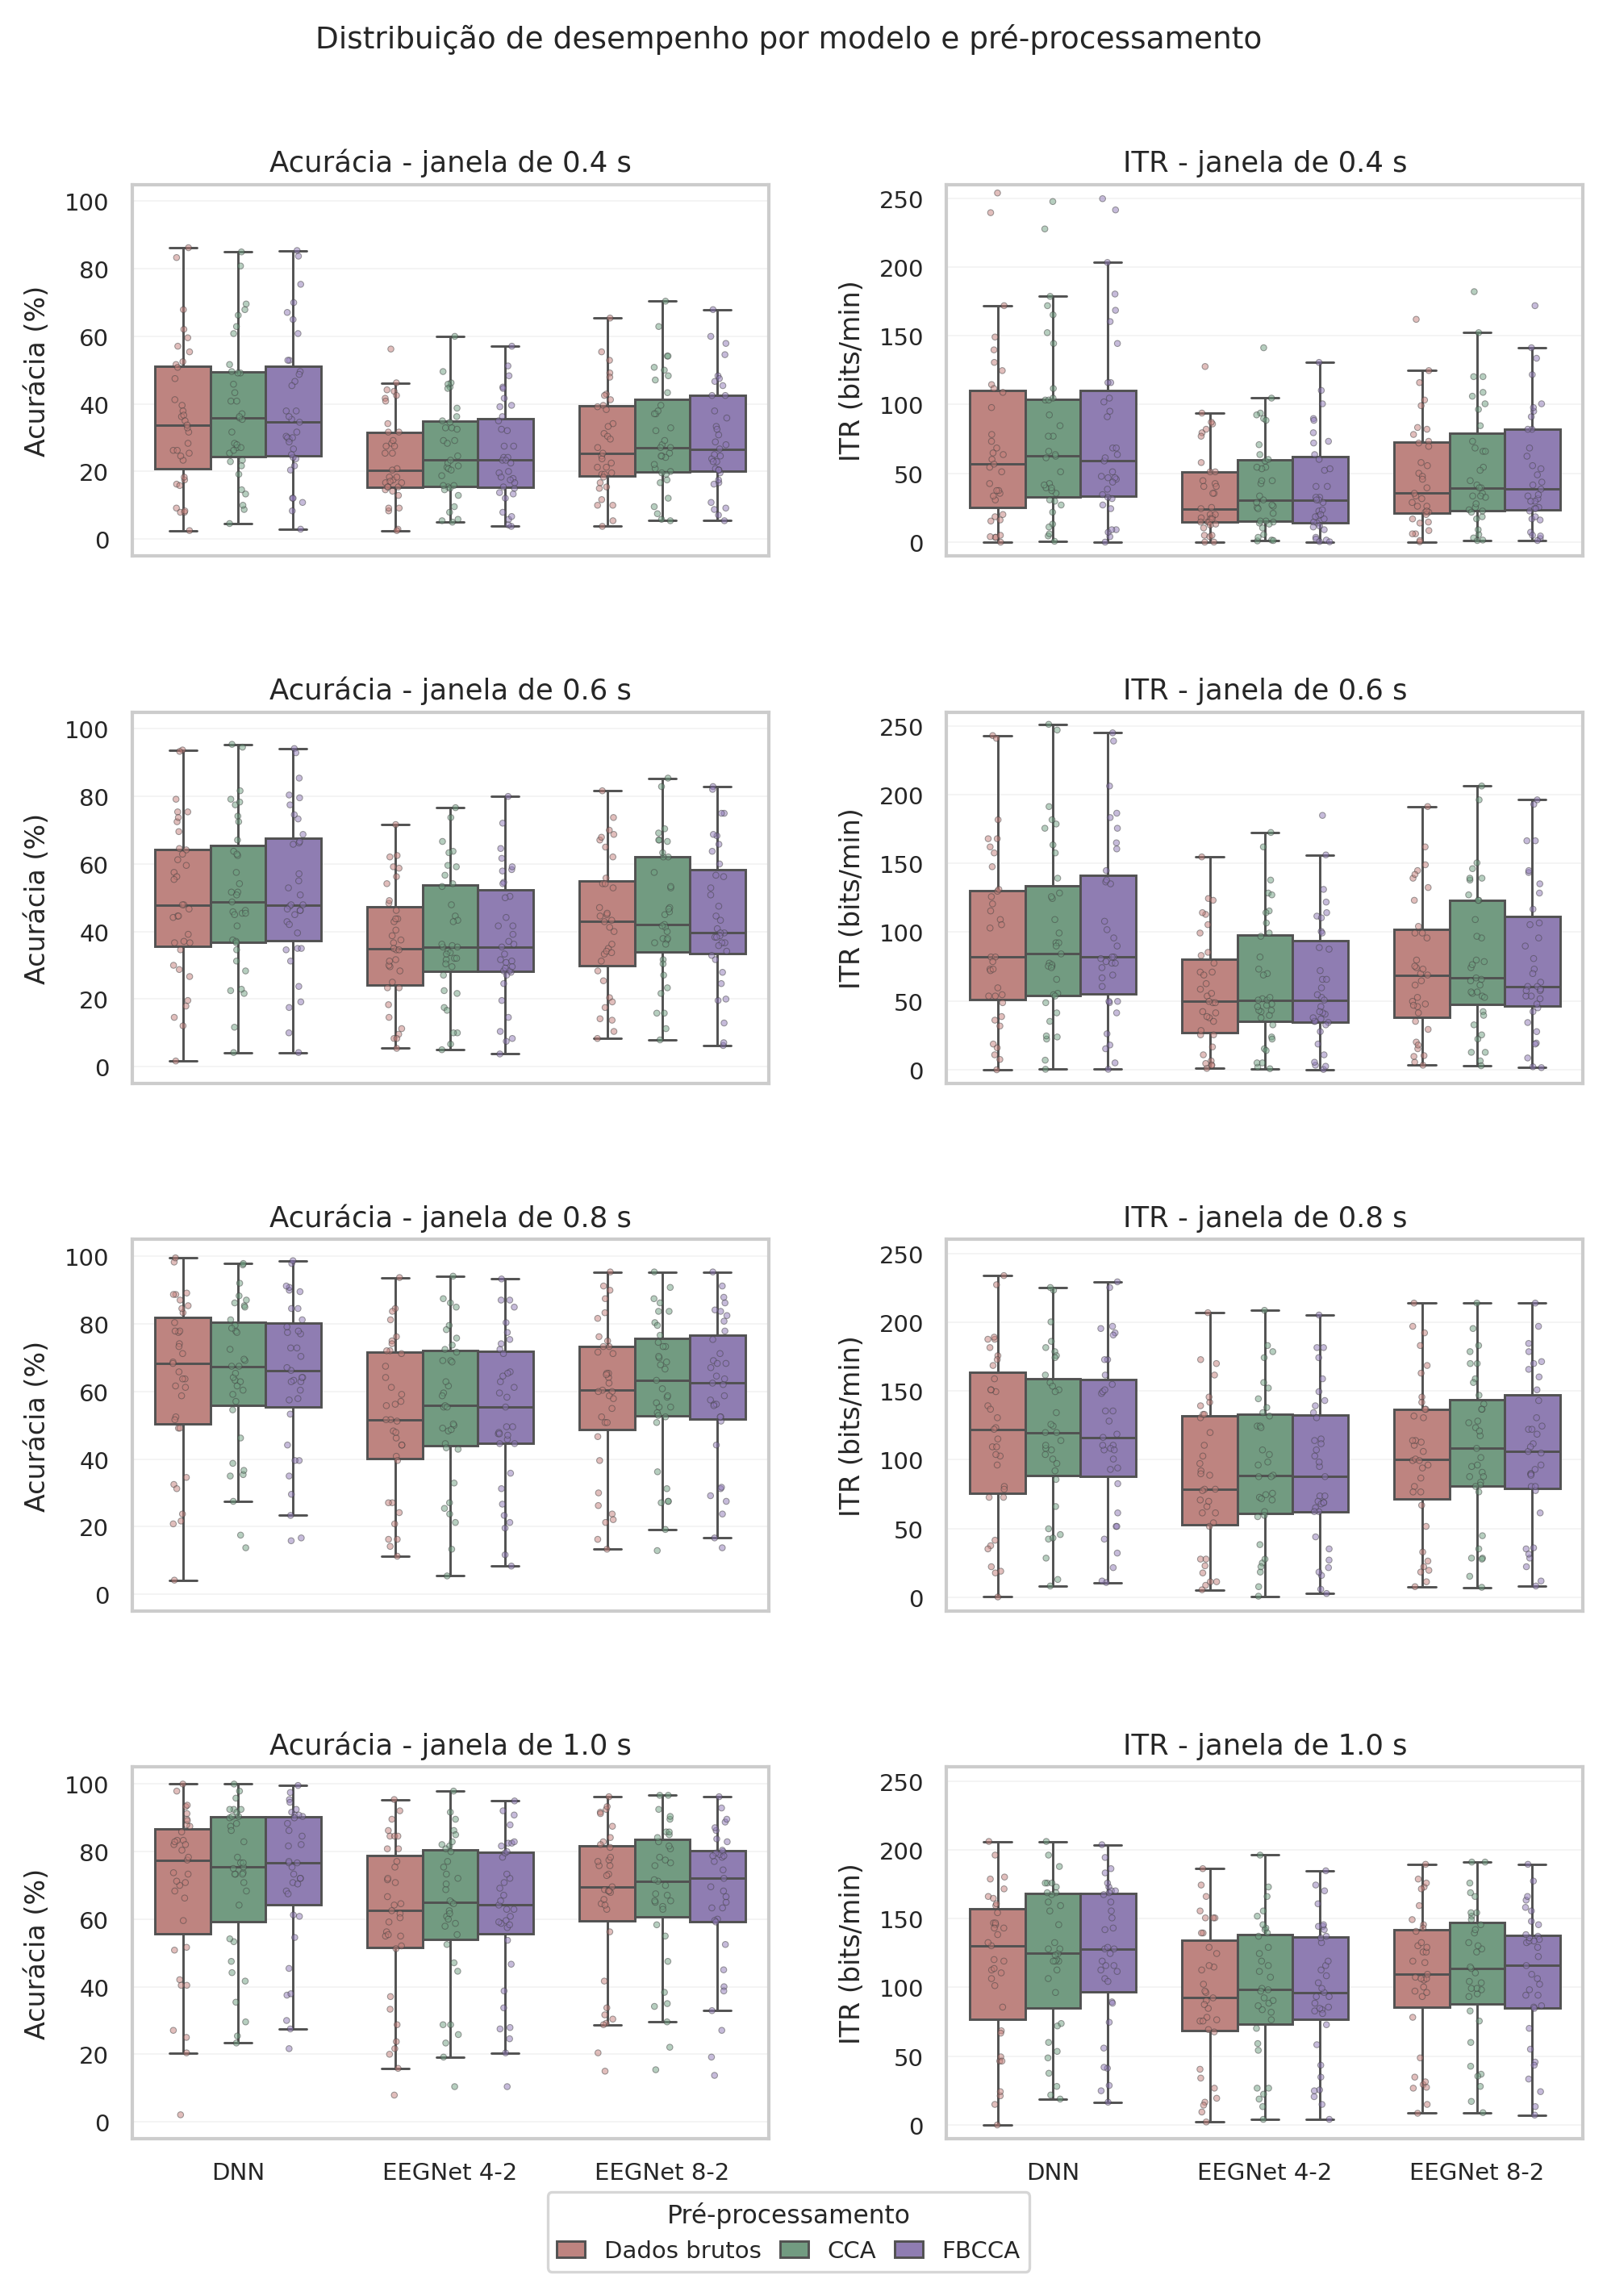

Tamanho da figura (polegadas): [6.7 9.5]
Limite de y da acurácia: (-5, 105)
Limite de y do ITR: (-10, 260)
Janelas plotadas na mesma figura: ['0.4 s', '0.6 s', '0.8 s', '1.0 s']


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


def experiment_labels(experiment_name):
    name = str(experiment_name).lower().replace("-", "_")
    if "eegnet_4_2" in name:
        model = "EEGNet 4-2"
    elif "eegnet_8_2" in name:
        model = "EEGNet 8-2"
    elif "dnn" in name:
        model = "DNN"
    else:
        model = str(experiment_name)

    if "fbcca" in name:
        condition = "FBCCA"
    elif name.startswith("cca_") or "_cca" in name:
        condition = "CCA"
    else:
        condition = "Dados brutos"
    return pd.Series({"model": model, "condition": condition})


plot_data = results.copy()
plot_data[["model", "condition"]] = plot_data["experiment"].apply(experiment_labels)
plot_data["accuracy_percent"] = plot_data["acuracia"] * 100

model_order = ["DNN", "EEGNet 4-2", "EEGNet 8-2"]
model_order = [model for model in model_order if model in plot_data["model"].unique()]
condition_order = ["Dados brutos", "CCA", "FBCCA"]
condition_order = [
    condition for condition in condition_order
    if condition in plot_data["condition"].unique()
]
condition_palette = {
    "Dados brutos": "#c47f7a",
    "CCA": "#6e9f80",
    "FBCCA": "#8e78b7",
}

durations = sorted(plot_data["window"].unique())
accuracy_limits = (-5, 105)
itr_limits = (-10, 260)

# Formato compacto para uma figura em página A4/Letter, orientação retrato.
sns.set_theme(style="whitegrid", context="paper", font_scale=0.8)
fig, axes = plt.subplots(
    len(durations),
    2,
    figsize=(6.7, 9.5),
    dpi=300,
    sharex=True,
    constrained_layout=False,
    squeeze=False,
)

for row, duration in enumerate(durations):
    duration_data = plot_data[plot_data["window"] == duration]
    for column, (metric, ylabel, title) in enumerate([
        ("accuracy_percent", "Acurácia (%)", "Acurácia"),
        ("itr", "ITR (bits/min)", "ITR"),
    ]):
        axis = axes[row, column]
        sns.boxplot(
            data=duration_data,
            x="model",
            y=metric,
            hue="condition",
            order=model_order,
            hue_order=condition_order,
            palette=condition_palette,
            width=0.78,
            showfliers=False,
            linewidth=0.7,
            saturation=0.85,
            ax=axis,
        )
        sns.stripplot(
            data=duration_data,
            x="model",
            y=metric,
            hue="condition",
            order=model_order,
            hue_order=condition_order,
            palette=condition_palette,
            dodge=True,
            jitter=0.12,
            size=1.8,
            alpha=0.5,
            linewidth=0.25,
            edgecolor="#404040",
            legend=False,
            ax=axis,
        )
        axis.set_xlim(-0.5, len(model_order) - 0.5)
        axis.set_ylim(accuracy_limits if metric == "accuracy_percent" else itr_limits)
        axis.set_xlabel("")
        axis.set_ylabel(ylabel, fontsize=8)
        axis.set_title(f"{title} - janela de {duration:.1f} s", fontsize=8.5, pad=4)
        axis.tick_params(axis="both", labelsize=7, pad=2)
        axis.grid(axis="y", linestyle="-", linewidth=0.4, alpha=0.25)
        axis.set_axisbelow(True)
        if row < len(durations) - 1:
            axis.tick_params(axis="x", labelbottom=False)

handles, labels = axes[0, 0].get_legend_handles_labels()
for axis in axes.flat:
    if axis.legend_ is not None:
        axis.legend_.remove()

fig.legend(
    handles[:len(condition_order)],
    labels[:len(condition_order)],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.012),
    ncol=len(condition_order),
    frameon=True,
    title="Pré-processamento",
    fontsize=7,
    title_fontsize=7.5,
    handlelength=1.2,
    columnspacing=0.8,
)
fig.suptitle(
    "Distribuição de desempenho por modelo e pré-processamento",
    fontsize=9,
    y=0.995,
)
fig.subplots_adjust(
    left=0.095,
    right=0.99,
    bottom=0.075,
    top=0.925,
    hspace=0.42,
    wspace=0.28,
)
plt.show()

print("Tamanho da figura (polegadas):", fig.get_size_inches())
print("Limite de y da acurácia:", accuracy_limits)
print("Limite de y do ITR:", itr_limits)
print("Janelas plotadas na mesma figura:", [f"{duration:.1f} s" for duration in durations])